# 1 - Dataset Overview

This notebook summarizes dataset composition, protocol, and collection timeline across waves.

Visuals: overview table · participant flow diagram · study timeline

## Import libraries and define paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pickle
from pathlib import Path

%matplotlib inline

np.random.seed(42)

# ── Paths & style ─────────────────────────────────────────────────────────────────────────────
from utils import (
    get_data_root, get_pkl_paths,
    GENDER_COLORS, COLORS, WAVE_LABELS, WAVE_KEYS, WAVE_TO_DIR,
    set_paper_style,
)

DATA_ROOT = get_data_root()
FILES     = get_pkl_paths(DATA_ROOT)
set_paper_style()


## Helper functions

In [2]:
from utils import (
    load_userinfo, load_wave_esm_userinfo,
    align_dates_relative, extract_gender,
    TRAIT_COLS, LABEL_NAMES,
    load_df_X_combined,
)

# ── Dataset paths for label loading ─────────────────────────────────────────────────────────────────────────────
DATA_ROOT_LABELS = Path(DATA_ROOT)
DATASETS = {
    "D-1": DATA_ROOT_LABELS / "D-1" / "full",
    "D-2": DATA_ROOT_LABELS / "D-2" / "full",
    "D-3": DATA_ROOT_LABELS / "D-3" / "full",
}

# ── Label loading helpers (for Trait Profile) ─────────────────────────────────────────────────────────────────────────────
def load_label_with_meta(dataset_path, label_nm):
    """Load label data with metadata from a dataset path."""
    pkl_path = next(dataset_path.glob(f"{label_nm}_personal-full*.pkl"))
    with open(pkl_path, "rb") as f:
        _x, y, pcode, _time_offset, timestamp = pickle.load(f)
    return np.asarray(y), np.asarray(pcode), pd.to_datetime(np.asarray(timestamp))


def load_user_traits(dataset_path):
    """Load user trait information."""
    wave_key = dataset_path.parent.name
    ui = load_userinfo(wave_key, DATA_ROOT, WAVE_TO_DIR)
    ui.columns = [c.lower() for c in ui.columns]
    keep_cols = ["pcode"] + [c for c in TRAIT_COLS if c in ui.columns]
    return ui[keep_cols].copy()


def build_user_label_means(dataset_path):
    """Build merged dataframe of user trait means per label."""
    frames = []
    for label in LABEL_NAMES:
        y, pcode, _ = load_label_with_meta(dataset_path, label)
        df = pd.DataFrame({"pcode": pcode, label: y})
        user_mean = df.groupby("pcode")[label].mean().reset_index()
        frames.append(user_mean)
    merged = frames[0]
    for df in frames[1:]:
        merged = merged.merge(df, on="pcode", how="inner")
    return merged


def build_merged_data():
    """Build merged dataset of user traits and label means across all datasets."""
    rows = []
    for ds_name, ds_path in DATASETS.items():
        traits = load_user_traits(ds_path)
        label_means = build_user_label_means(ds_path)
        merged = traits.merge(label_means, on="pcode", how="inner")
        merged["dataset"] = ds_name
        rows.append(merged)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def zscore_by_dataset(df, cols, group_col="Wave"):
    """Z-score normalize specified columns within each dataset group."""
    return df.groupby(group_col)[cols].transform(lambda x: (x - x.mean()) / x.std())


def compute_label_drift(df, label, participant_ids, timestamps, bin_hours=24, max_days=30):
    """Compute label presence proportion over relative time bins."""
    if df.empty or label not in df.columns:
        return pd.Series(dtype=float)
    meta = pd.DataFrame({
        'participant_id': participant_ids,
        'timestamp': pd.to_datetime(timestamps)
    })
    meta = align_dates_relative(meta, "participant_id", date_col="timestamp", output_col="relative_day")
    meta["label_value"] = df[label].values
    meta = meta.loc[meta["relative_day"].notna() & meta["label_value"].notna()].copy()
    meta = meta.loc[meta["relative_day"] <= max_days].copy()
    meta["_bin"] = (meta["relative_day"] * 24 / bin_hours).astype(int)
    meta["label_bin"] = (meta["label_value"] > 0).astype(int)
    return meta.groupby("_bin")["label_bin"].mean()


def _to_ms_array(x: pd.Series) -> np.ndarray:
    v = pd.to_numeric(x, errors="coerce").to_numpy(dtype="float64")
    ms = np.full(v.shape, np.nan, dtype="float64")
    m_sec = (v > 1e8)   & (v < 1e11)
    m_ms  = (v >= 1e11) & (v < 1e14)
    m_us  = (v >= 1e14) & (v < 1e17)
    m_ns  = (v >= 1e17) & (v < 1e20)
    ms[m_sec] = v[m_sec] * 1e3
    ms[m_ms]  = v[m_ms]
    ms[m_us]  = v[m_us] / 1e3
    ms[m_ns]  = v[m_ns] / 1e6
    mask_nan = np.isnan(ms)
    if mask_nan.any():
        dt_str = pd.to_datetime(x[mask_nan], utc=True, errors="coerce")
        ms[mask_nan] = dt_str.view("int64") / 1e6
    return ms


def robust_to_utc_datetime(s: pd.Series) -> pd.Series:
    ms = _to_ms_array(s)
    min_ms = pd.Timestamp("2010-01-01", tz="UTC").value / 1e6
    max_ms = pd.Timestamp("2035-12-31", tz="UTC").value / 1e6
    valid = (ms >= min_ms) & (ms <= max_ms)
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns, UTC]")
    out[valid] = pd.to_datetime(ms[valid], unit="ms", utc=True)
    return out

## Data loading helpers

In [3]:
# ── ESM and UserInfo data ─────────────────────────────────────────────────────────────────────────────
esm_by_wave, userinfo_by_wave, esm_all = load_wave_esm_userinfo(
    WAVE_KEYS,
    DATA_ROOT,
    WAVE_TO_DIR,
    include_userinfo=True,
    include_study_day=True,
)

# ── Combined sensor dataframe ─────────────────────────────────────────────────────────────────────────────
df_X_combined = load_df_X_combined(DATA_ROOT)

---
## Visuals

### Participant Flow Diagram

Insight: Shows how many participants were recruited, completed, and excluded per wave.

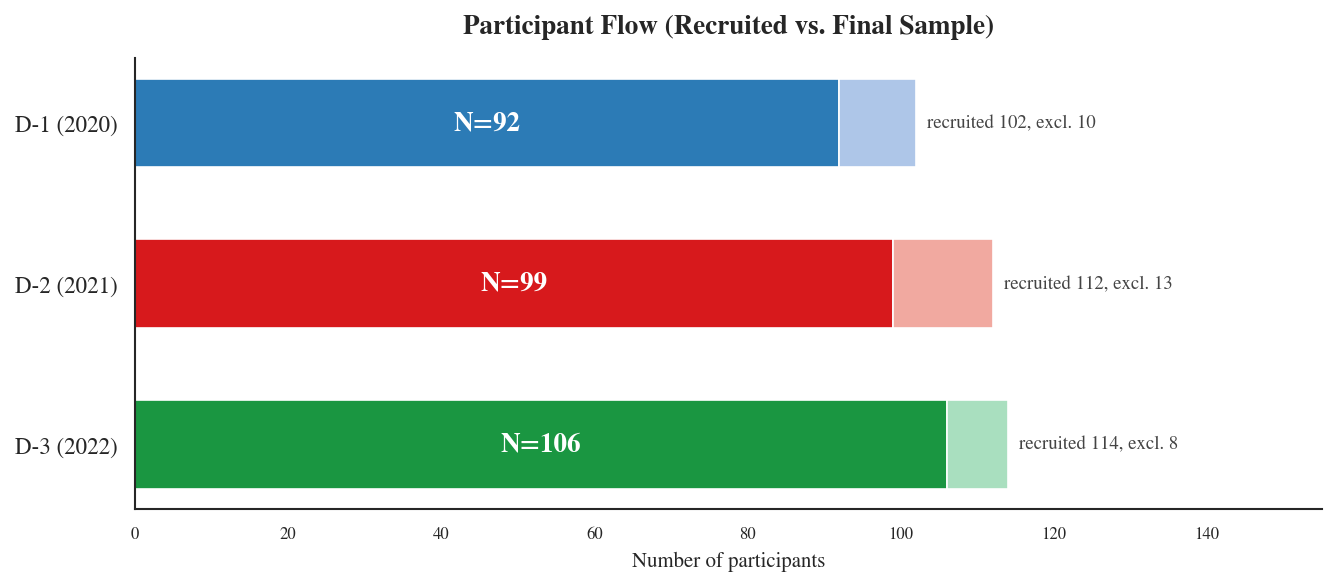

In [4]:
# Participant counts
recruited = [userinfo_by_wave[k].shape[0] for k in WAVE_KEYS]
final = [esm_by_wave[k]["Pcode"].nunique() for k in WAVE_KEYS]
excluded = [r - f for r, f in zip(recruited, final)]

# --- Colors (dark = final, light = excluded) ---
colors_dark  = ["#2C7BB6", "#D7191C", "#1A9641"]   # blue, red, green
colors_light = ["#AEC6E8", "#F1A9A0", "#A9DFBF"]   # matching pastels

fig, ax = plt.subplots(figsize=(9, 4))

y_pos = np.arange(len(WAVE_KEYS))
bar_height = 0.55

for i, (f, e, cd, cl) in enumerate(zip(final, excluded, colors_dark, colors_light)):
    # Main (final) bar
    ax.barh(y_pos[i], f, height=bar_height, color=cd, zorder=2)
    # Excluded extension (stacked)
    ax.barh(y_pos[i], e, height=bar_height, left=f, color=cl, zorder=2)

    # N= label inside the dark bar
    ax.text(f / 2, y_pos[i], f"N={f}", ha="center", va="center",
            fontsize=13, fontweight="bold", color="white", zorder=3)

    # Annotation to the right
    r = f + e
    ax.text(r + 1.5, y_pos[i], f"recruited {r}, excl. {e}",
            va="center", fontsize=9, color="#444444")

# --- Axes formatting ---
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{lbl}" for k, lbl in zip(WAVE_KEYS, WAVE_LABELS)],
                   fontsize=11)
ax.set_xlabel("Number of participants", fontsize=10)
ax.set_xlim(0, 155)
ax.set_title("Participant Flow (Recruited vs. Final Sample)",
             fontweight="bold", fontsize=13, pad=12)

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis() 

plt.tight_layout()
plt.show()


### Age-Gender Distribution

Insight: Age and gender distribution of the combined study sample.

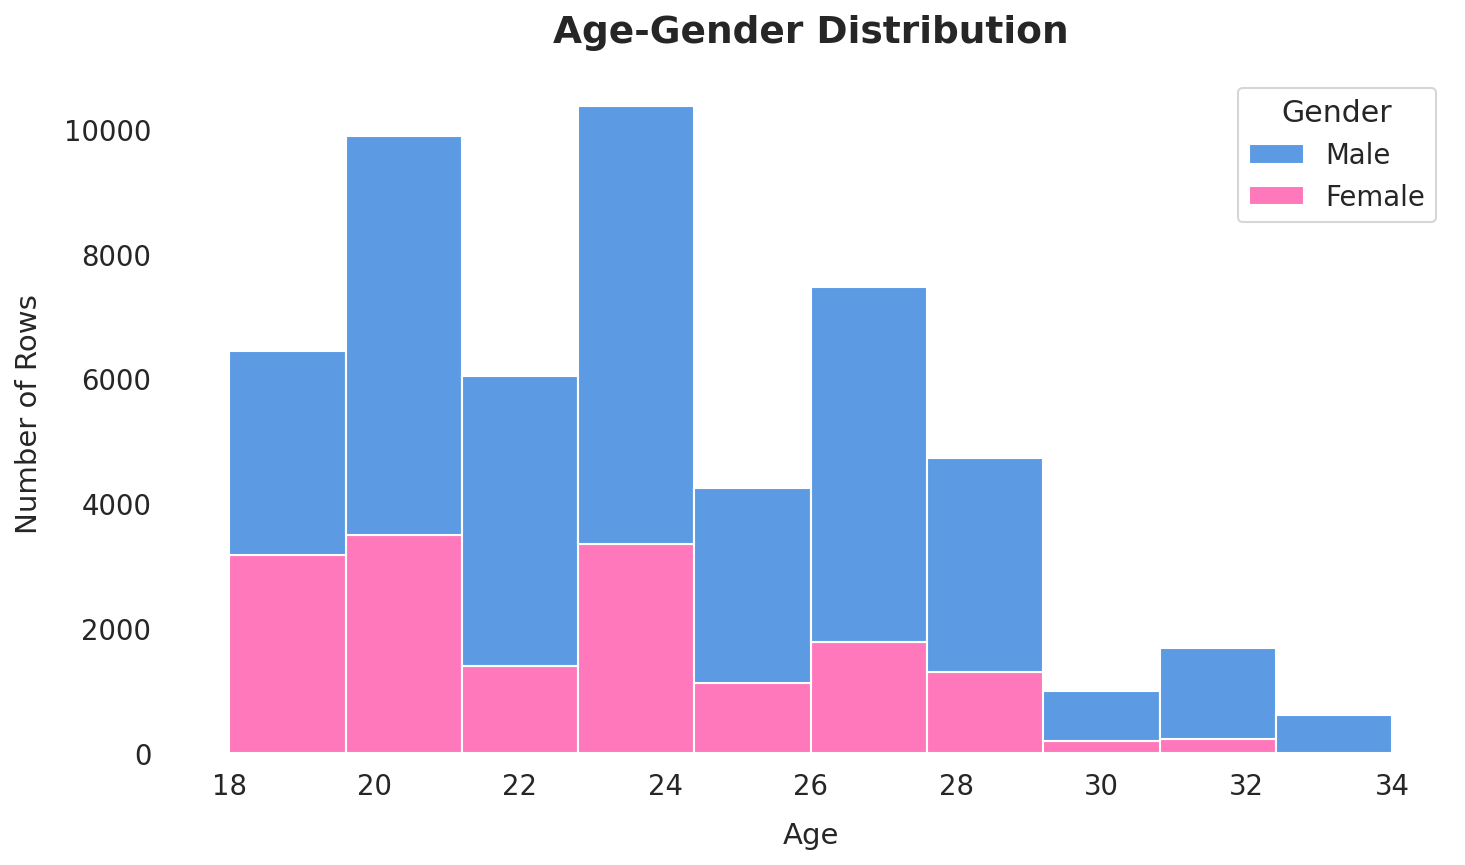

In [ ]:
sns.set_theme(style="white", font_scale=1.2)
plt.figure(figsize=(10, 6), dpi=150)

ax = sns.histplot(
    data=df_X_combined,
    x="PIF#age",
    hue="PIF#gender",
    multiple="stack",
    bins=10,
    palette=GENDER_COLORS,
    edgecolor="white",
    alpha=0.9
)

legend = ax.get_legend()
legend.set_title("Gender")

for text in legend.texts:
    if text.get_text() == "M":
        text.set_text("Male")
    elif text.get_text() == "F":
        text.set_text("Female")

plt.title("Age-Gender Distribution", fontsize=18, weight="bold", pad=15)
plt.xlabel("Age", fontsize=14, labelpad=10)
plt.ylabel("Number of Rows", fontsize=14, labelpad=10)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Participant Demographics
Insight: Summary statistics for age and gender per wave.

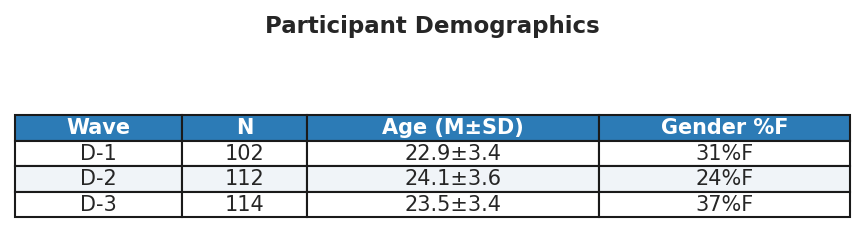

In [6]:
table_data = []
for wave in WAVE_KEYS:
    ui = userinfo_by_wave.get(wave)
    if ui is None or ui.empty:
        continue
    n = len(ui)
    age_col = "PIF#age" if "PIF#age" in ui.columns else ("Age" if "Age" in ui.columns else None)
    
    age_mean = age_std = "-"
    if age_col and age_col in ui.columns:
        ages = ui[age_col].dropna()
        if len(ages) > 0:
            age_mean = f"{ages.mean():.1f}"
            age_std = f"{ages.std():.1f}"
    
    gender_pct = "-"
    if "Gender" in ui.columns:
        gender = ui["Gender"].astype(str).str.upper()
        gender = gender.where(gender.isin(["M", "F"]))
        total = gender.notna().sum()
        if total > 0:
            pct = (gender == "F").sum() / total * 100
            gender_pct = f"{pct:.0f}%F"
    
    table_data.append({"Wave": wave, "N": n, "Age (M±SD)": f"{age_mean}±{age_std}", "Gender %F": gender_pct})

if table_data:
    table_df = pd.DataFrame(table_data)
    fig, ax = plt.subplots(figsize=(6, 1.5))
    ax.axis("off")
    tbl = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc="center",
        loc="center",
        colWidths=[0.2, 0.15, 0.35, 0.3]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.8)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#2C7BB6")
            cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#F0F4F8")
        else:
            cell.set_facecolor("white")
    plt.suptitle("Participant Demographics", fontsize=11, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("No demographics data available")

### ESM Response Time-of-Day Distribution

Insight: When during the day participants respond to ESM prompts.

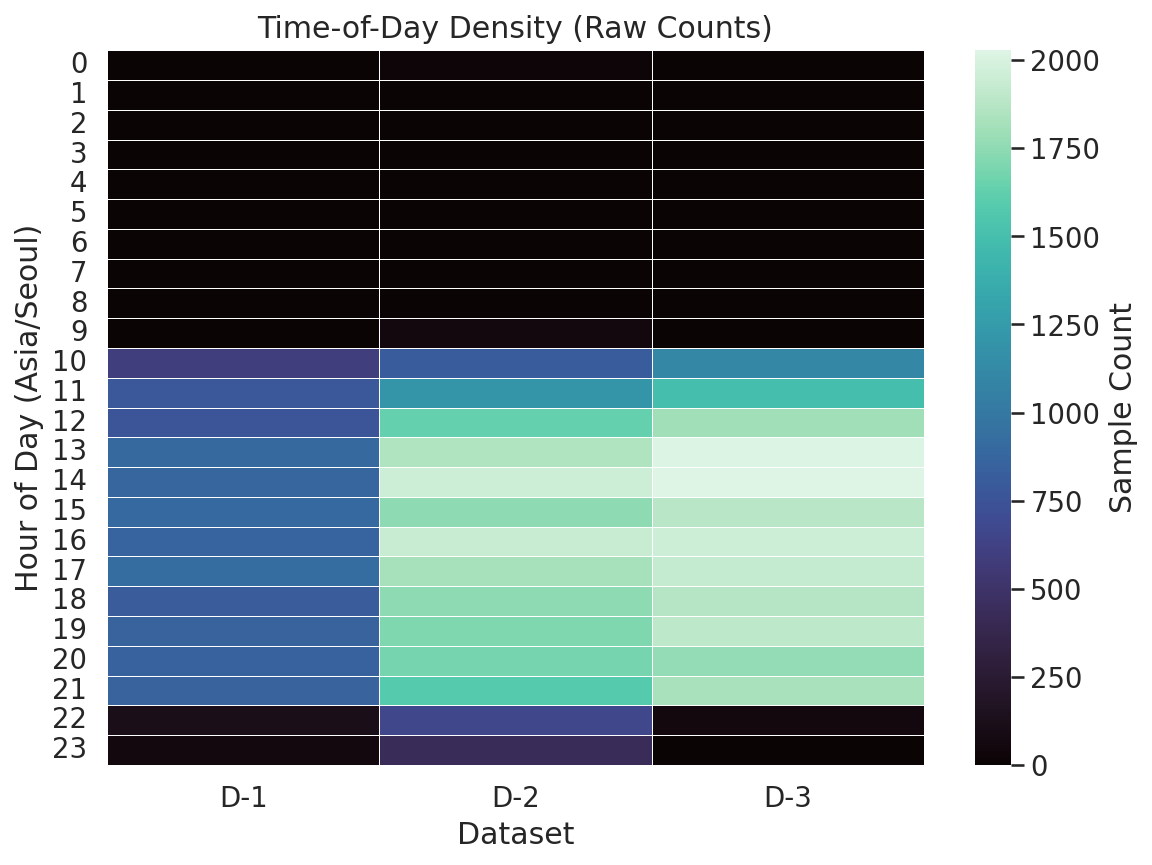

In [7]:
ts_col = "PIF#timestamp"
dt_local = robust_to_utc_datetime(df_X_combined[ts_col]).dt.tz_convert("Asia/Seoul")

df_hour = (
    df_X_combined
      .assign(datetime=dt_local)
      .loc[dt_local.notna(), ["META#dataset", "datetime"]]
      .assign(hour=lambda d: d["datetime"].dt.hour)
)

counts = (
    df_hour
      .groupby(["hour", "META#dataset"])
      .size()
      .unstack(fill_value=0)
      .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    counts,
    cmap="mako",
    cbar_kws={"label": "Sample Count"},
    linewidths=0.3,
    linecolor="white"
)
plt.title("Time-of-Day Density (Raw Counts)")
plt.xlabel("Dataset")
plt.ylabel("Hour of Day (Asia/Seoul)")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Time-of-Day Activity Distribution

Insight: Hourly ESM response distribution across waves, normalised to proportion per wave.

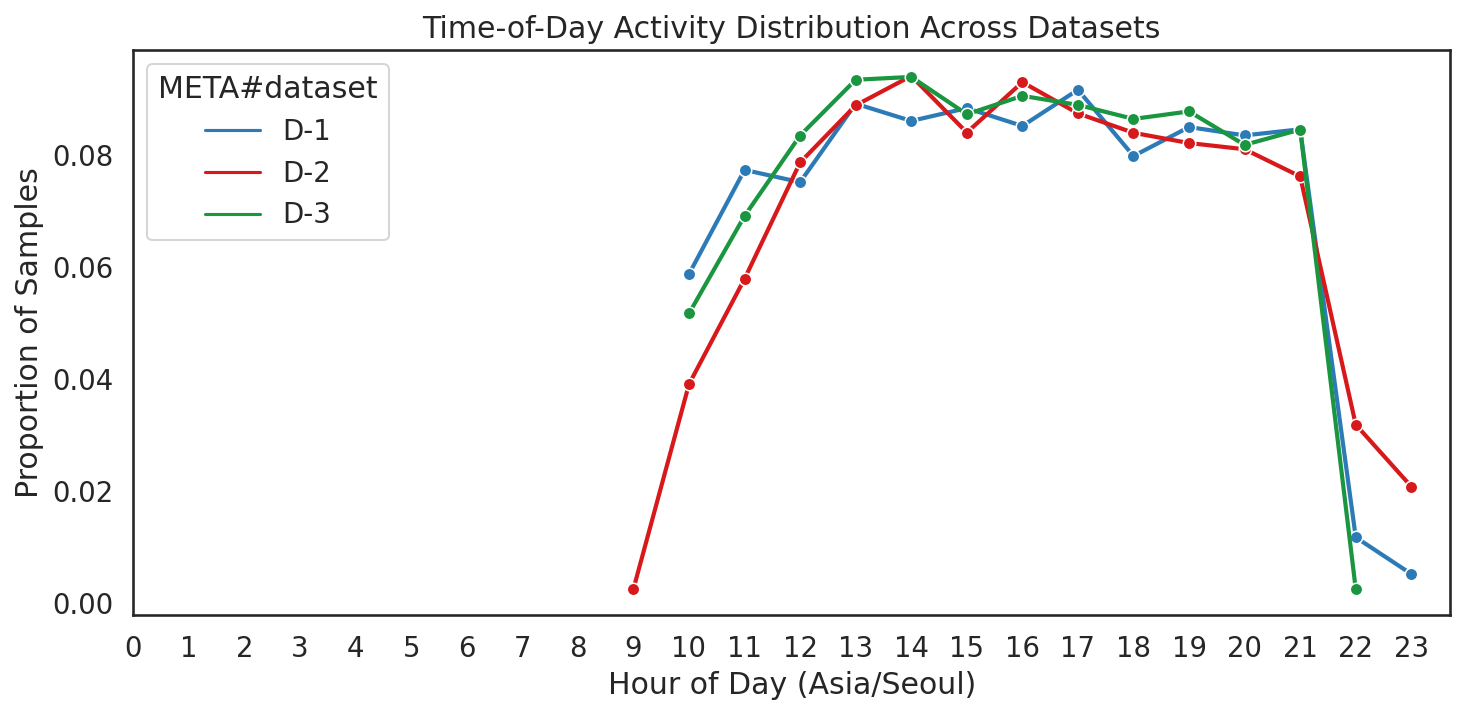

In [8]:
hourly = (
    df_X_combined
        .assign(datetime=dt_local)
        .loc[dt_local.notna()]
        .assign(hour=lambda d: d["datetime"].dt.hour)
        .groupby(["META#dataset", "hour"])
        .size()
        .reset_index(name="sample_count")
)

# keep only hours with ≥ 20 samples per dataset
hourly = hourly[hourly["sample_count"] >= 20]

hourly["proportion"] = (
    hourly.groupby("META#dataset")["sample_count"]
         .transform(lambda x: x / x.sum())
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hourly,
    x="hour",
    y="proportion",
    hue="META#dataset",
    palette=COLORS,
    marker="o",
    linewidth=2.0,
)
plt.xticks(range(0, 24))
plt.xlabel("Hour of Day (Asia/Seoul)")
plt.ylabel("Proportion of Samples")
plt.title("Time-of-Day Activity Distribution Across Datasets")
plt.tight_layout()
plt.show()

## Participant Demographics

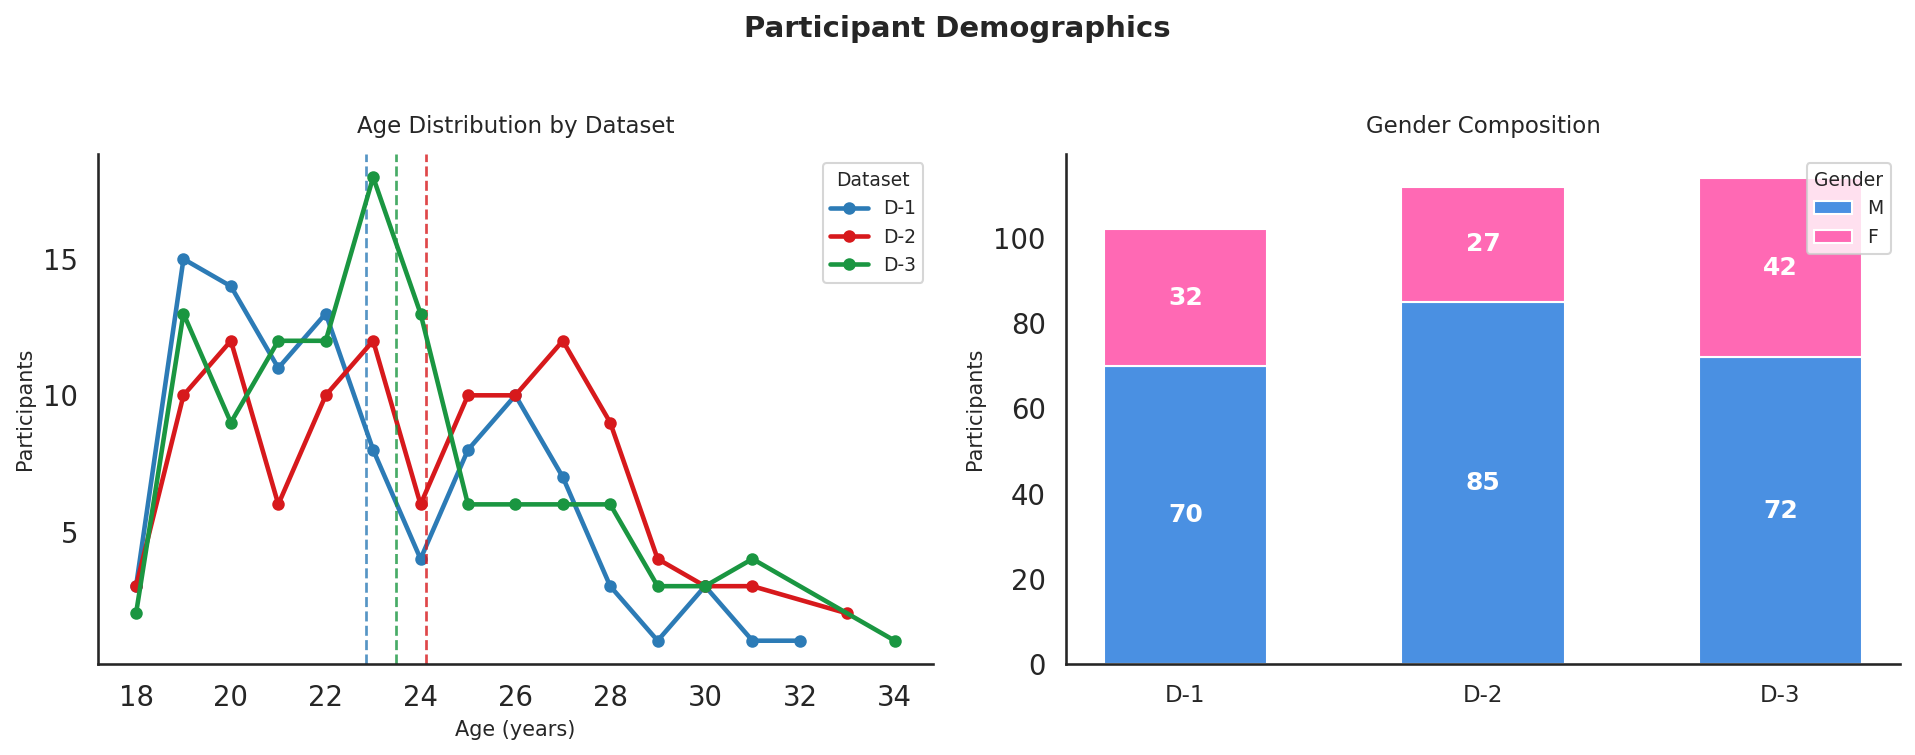

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Participant Demographics", fontweight="bold", fontsize=14, y=1.01)

# ── LEFT: Age Distribution ────────────────────────────────────────────────────

for wave in WAVE_KEYS:
    ui = userinfo_by_wave.get(wave)
    if ui is None or ui.empty:
        continue
    age_col = "Age" if "Age" in ui.columns else "PIF#age"
    if age_col not in ui.columns:
        continue
    ages = ui[age_col].dropna()
    age_counts = ages.value_counts().sort_index()

    ax1.plot(age_counts.index, age_counts.values,
             marker="o", label=wave, color=COLORS[wave],
             linewidth=2.2, markersize=5)

    ax1.axvline(ages.mean(), color=COLORS[wave],
                linestyle="--", linewidth=1.3, alpha=0.8)

ax1.set_title("Age Distribution by Dataset", fontsize=11, pad=10)
ax1.set_xlabel("Age (years)", fontsize=10)
ax1.set_ylabel("Participants", fontsize=10)
ax1.yaxis.set_major_locator(plt.MultipleLocator(5))   # integer ticks: 0, 5, 10 …
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: str(int(v))))
ax1.legend(title="Dataset", fontsize=9, title_fontsize=9, frameon=True)
ax1.grid(False)                                        # ← remove grid
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ── RIGHT: Gender Composition ─────────────────────────────────────────────────
gender_data = []
for wave in WAVE_KEYS:
    ui = userinfo_by_wave.get(wave)
    if ui is None or ui.empty:
        continue
    gender = ui["Gender"].astype(str).str.upper()
    gender = gender.where(gender.isin(["M", "F"]))
    temp = pd.DataFrame({"Wave": wave, "Gender": gender})
    gender_data.append(temp)

if gender_data:
    gender_df     = pd.concat(gender_data, ignore_index=True)
    gender_counts = (gender_df.groupby(["Wave", "Gender"])
                               .size()
                               .unstack(fill_value=0)
                               .reindex(WAVE_KEYS))

    x    = np.arange(len(WAVE_KEYS))
    w    = 0.55                                        # wider bars like reference
    male = gender_counts.get("M", pd.Series([0]*len(WAVE_KEYS), index=WAVE_KEYS))
    fem  = gender_counts.get("F", pd.Series([0]*len(WAVE_KEYS), index=WAVE_KEYS))

    ax2.bar(x, male, width=w, color=GENDER_COLORS["M"], label="M", zorder=2)
    ax2.bar(x, fem,  width=w, bottom=male,
            color=GENDER_COLORS["F"], label="F", zorder=2)

    for i, (m, f) in enumerate(zip(male, fem)):
        if m > 0:
            ax2.text(x[i], m / 2, str(int(m)),
                     ha="center", va="center",
                     color="white", fontweight="bold", fontsize=12)
        if f > 0:
            ax2.text(x[i], m + f / 2, str(int(f)),
                     ha="center", va="center",
                     color="white", fontweight="bold", fontsize=12)

    ax2.set_title("Gender Composition", fontsize=11, pad=10)
    ax2.set_ylabel("Participants", fontsize=10)
    ax2.set_xticks(x)
    ax2.set_xticklabels(WAVE_KEYS, fontsize=11)
    ax2.yaxis.set_major_locator(plt.MultipleLocator(20))  # 0, 20, 40 …
    ax2.legend(title="Gender", fontsize=9, title_fontsize=9, frameon=True)
    ax2.grid(False)                                        # ← remove grid
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
else:
    ax2.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.show()

### Stress Drift - Per-User Aligned (All Datasets + Combined)

Insight: Stress label proportions over participation time, per-user aligned with gender breakdown.
Plots individual datasets (D-1, D-2, D-3) and the combined dataset.

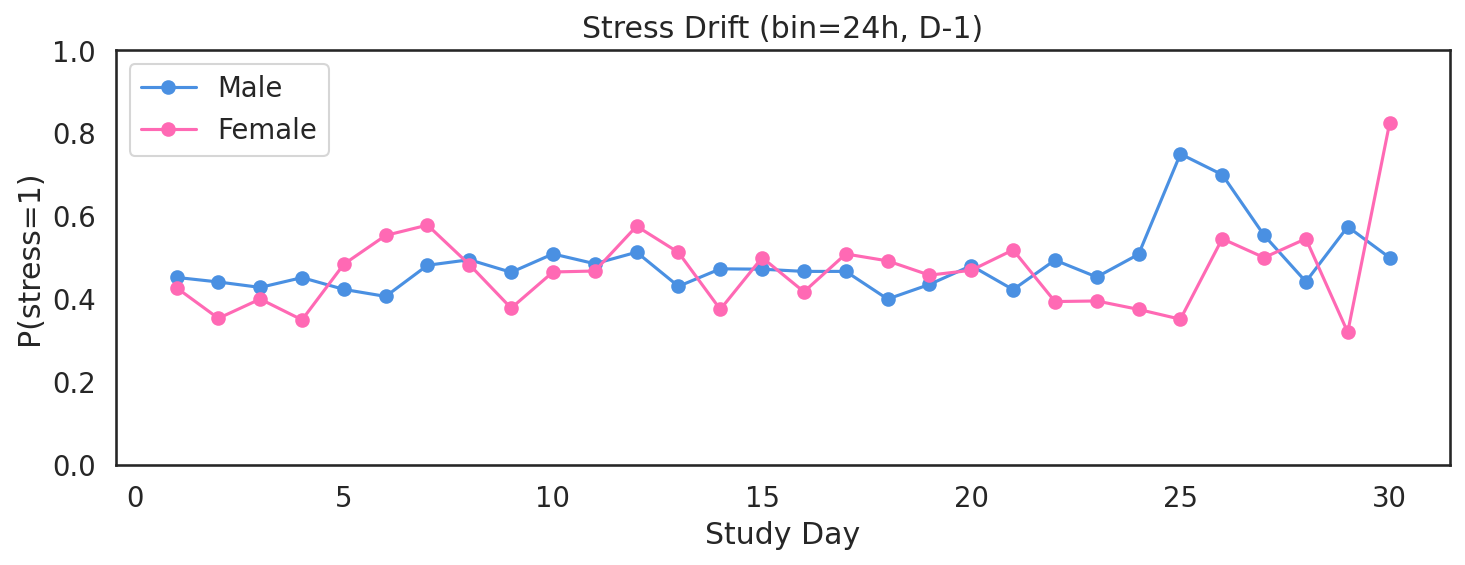

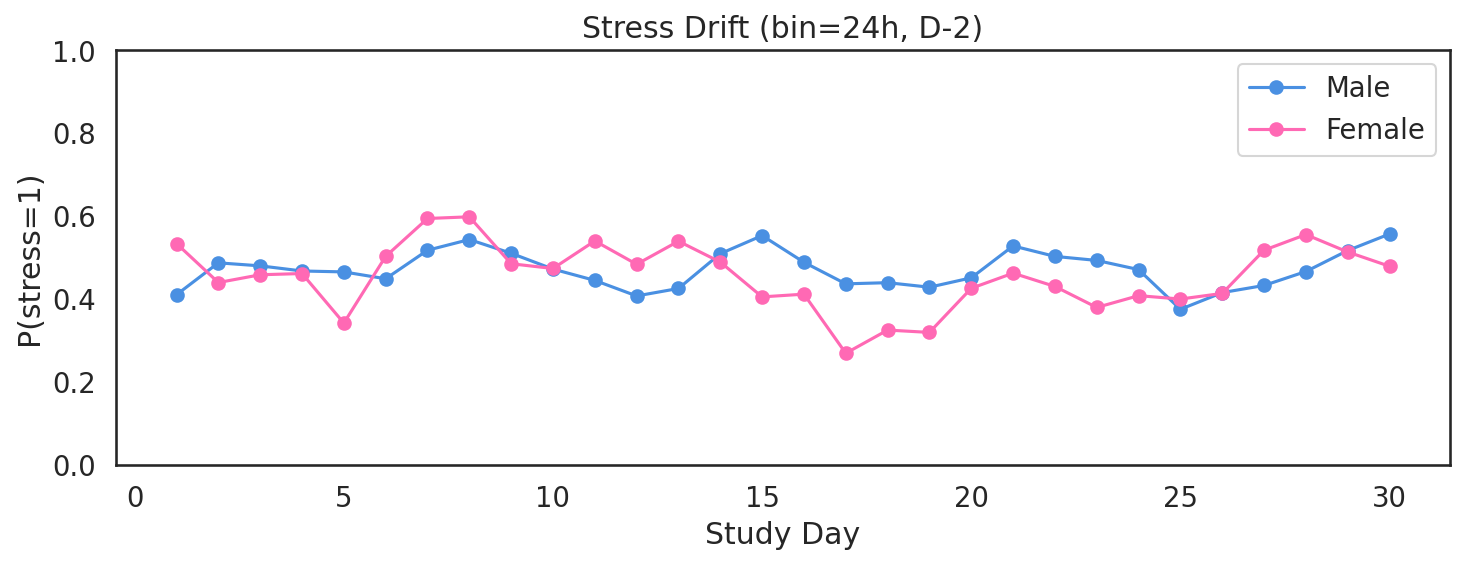

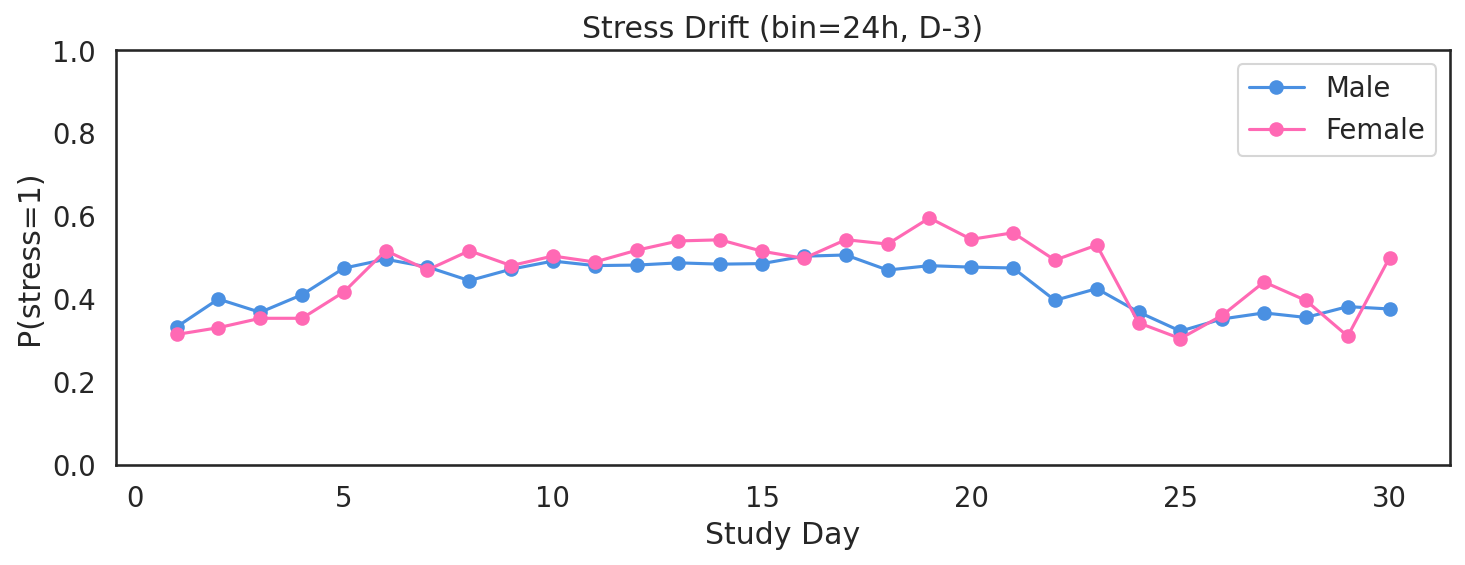

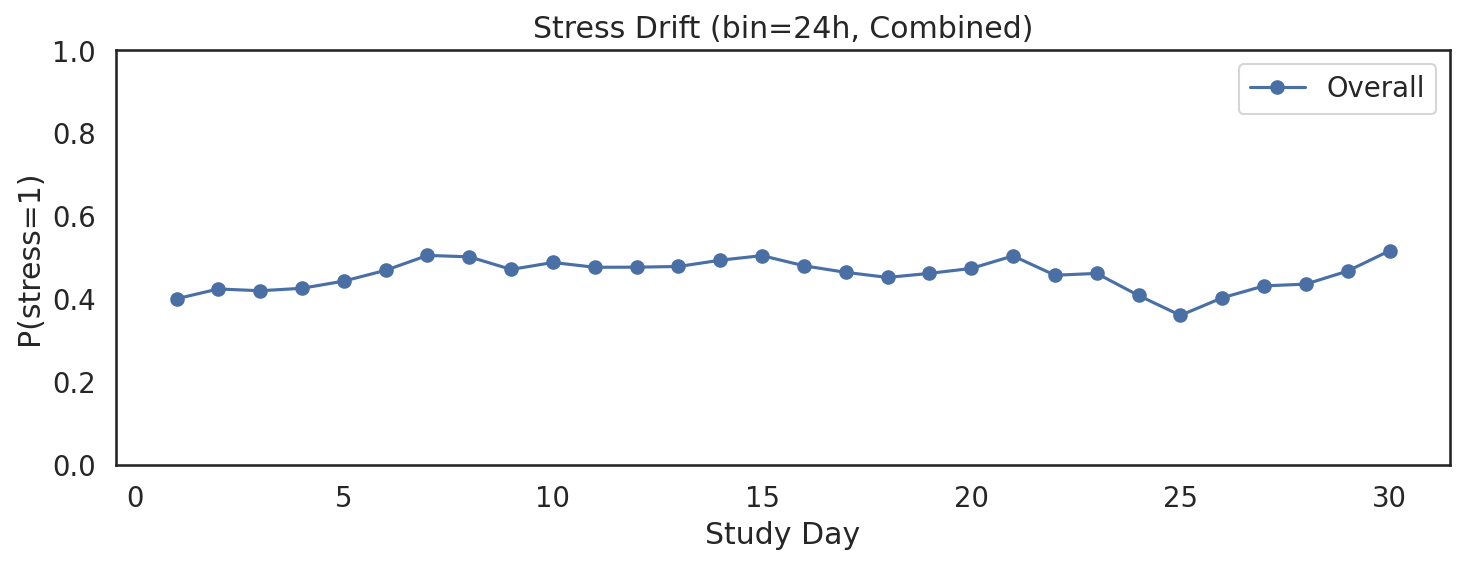

In [19]:
_BIN_HOURS = 24
_WINDOW_DAYS = 30

# ── Build globally anchored metadata per dataset ──────────────────────────────────────────
# Anchor rule: everyone is shifted so their first response date maps to the earliest
_plot_targets = []

for _name, _path in FILES.items():
    _df_raw, _y, _groups, _t, _datetimes = pd.read_pickle(_path)
    _gender = extract_gender(_df_raw) if len(_df_raw) == len(_groups) else pd.Series(np.nan, index=np.arange(len(_groups)))

    _meta = pd.DataFrame({
        "participant_id": _groups,
        "timestamp": pd.to_datetime(_datetimes, errors="coerce"),
        "label": _y,
        "gender": _gender.values,
    }).dropna(subset=["participant_id", "timestamp", "label"])

    if _meta.empty:
        _plot_targets.append((_name, _meta, pd.NaT))
        continue

    _anchor_date = _meta["timestamp"].dt.normalize().min()
    _user_start_date = _meta.groupby("participant_id")["timestamp"].transform(lambda s: s.dt.normalize().min())

    # Shift each user backward/forward by whole-day offset so user start aligns to anchor.
    _day_offset = (_user_start_date - _anchor_date).dt.days
    _meta["aligned_timestamp"] = _meta["timestamp"] - pd.to_timedelta(_day_offset, unit="D")

    _window_end = _anchor_date + pd.Timedelta(days=_WINDOW_DAYS - 1)
    _meta = _meta[
        (_meta["aligned_timestamp"].dt.normalize() >= _anchor_date)
        & (_meta["aligned_timestamp"].dt.normalize() <= _window_end)
    ].copy()

    _meta["aligned_day"] = (_meta["aligned_timestamp"].dt.normalize() - _anchor_date).dt.days + 1
    _plot_targets.append((_name, _meta, _anchor_date))

# ── Combined dataset with the same global-anchor logic ────────────────────────────────────
_df_comb = df_X_combined.copy()
_df_comb["_participant"] = _df_comb["META#dataset"] + "_" + _df_comb["PIF#participantID"].astype(str)

_meta_comb = pd.DataFrame({
    "participant_id": _df_comb["_participant"],
    "timestamp": pd.to_datetime(_df_comb["PIF#timestamp"], errors="coerce"),
    "label": _df_comb["PIF#stress_label"].values,
}).dropna(subset=["participant_id", "timestamp", "label"])

if _meta_comb.empty:
    _plot_targets.append(("Combined", _meta_comb, pd.NaT))
else:
    _anchor_date = _meta_comb["timestamp"].dt.normalize().min()
    _user_start_date = _meta_comb.groupby("participant_id")["timestamp"].transform(lambda s: s.dt.normalize().min())

    _day_offset = (_user_start_date - _anchor_date).dt.days
    _meta_comb["aligned_timestamp"] = _meta_comb["timestamp"] - pd.to_timedelta(_day_offset, unit="D")

    _window_end = _anchor_date + pd.Timedelta(days=_WINDOW_DAYS - 1)
    _meta_comb = _meta_comb[
        (_meta_comb["aligned_timestamp"].dt.normalize() >= _anchor_date)
        & (_meta_comb["aligned_timestamp"].dt.normalize() <= _window_end)
    ].copy()

    _meta_comb["aligned_day"] = (_meta_comb["aligned_timestamp"].dt.normalize() - _anchor_date).dt.days + 1
    _plot_targets.append(("Combined", _meta_comb, _anchor_date))

# ── Plot stress drift ───────────────────────────────────────────────────────────────────────
# Individual waves: Male/Female + Overall
# Combined: Overall only
for _title, _meta, _anchor_date in _plot_targets:
    if _meta.empty:
        print(f"[skip] {_title}: no data after alignment/windowing")
        continue

    _d = _meta[["aligned_day", "label"]].copy()
    if "gender" in _meta.columns:
        _d["gender"] = _meta["gender"].astype(str).str.upper().where(_meta["gender"].astype(str).str.upper().isin(["M", "F"]))

    _d["_bin"] = (((_d["aligned_day"] - 1) * 24) / _BIN_HOURS).astype(int) + 1
    _series = _d.groupby("_bin")["label"].mean()

    plt.figure(figsize=(10, 4))

    if _title == "Combined":
        plt.plot(_series.index, _series.values, marker="o", color="#4A6FA5", label="Overall")
    elif "gender" in _d.columns and _d["gender"].notna().any():
        _by_gender = _d.dropna(subset=["gender"]).groupby(["_bin", "gender"])["label"].mean().unstack()
        if "M" in _by_gender.columns:
            plt.plot(_by_gender.index, _by_gender["M"], marker="o", color=GENDER_COLORS["M"], label="Male")
        if "F" in _by_gender.columns:
            plt.plot(_by_gender.index, _by_gender["F"], marker="o", color=GENDER_COLORS["F"], label="Female")
    else:
        # Fallback: if gender is unavailable in an individual dataset, show overall.
        plt.plot(_series.index, _series.values, marker="o", color="#4A6FA5", label="Overall")

    plt.title(
        f"Stress Drift (bin={_BIN_HOURS}h, {_title})"
    )
    plt.xlabel("Study Day")
    plt.ylabel("P(stress=1)")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Trait Profile - Low vs High Label Groups

Insight: Compare personality traits between participants with low vs high values across arousal, valence, task disturbance, and stress.

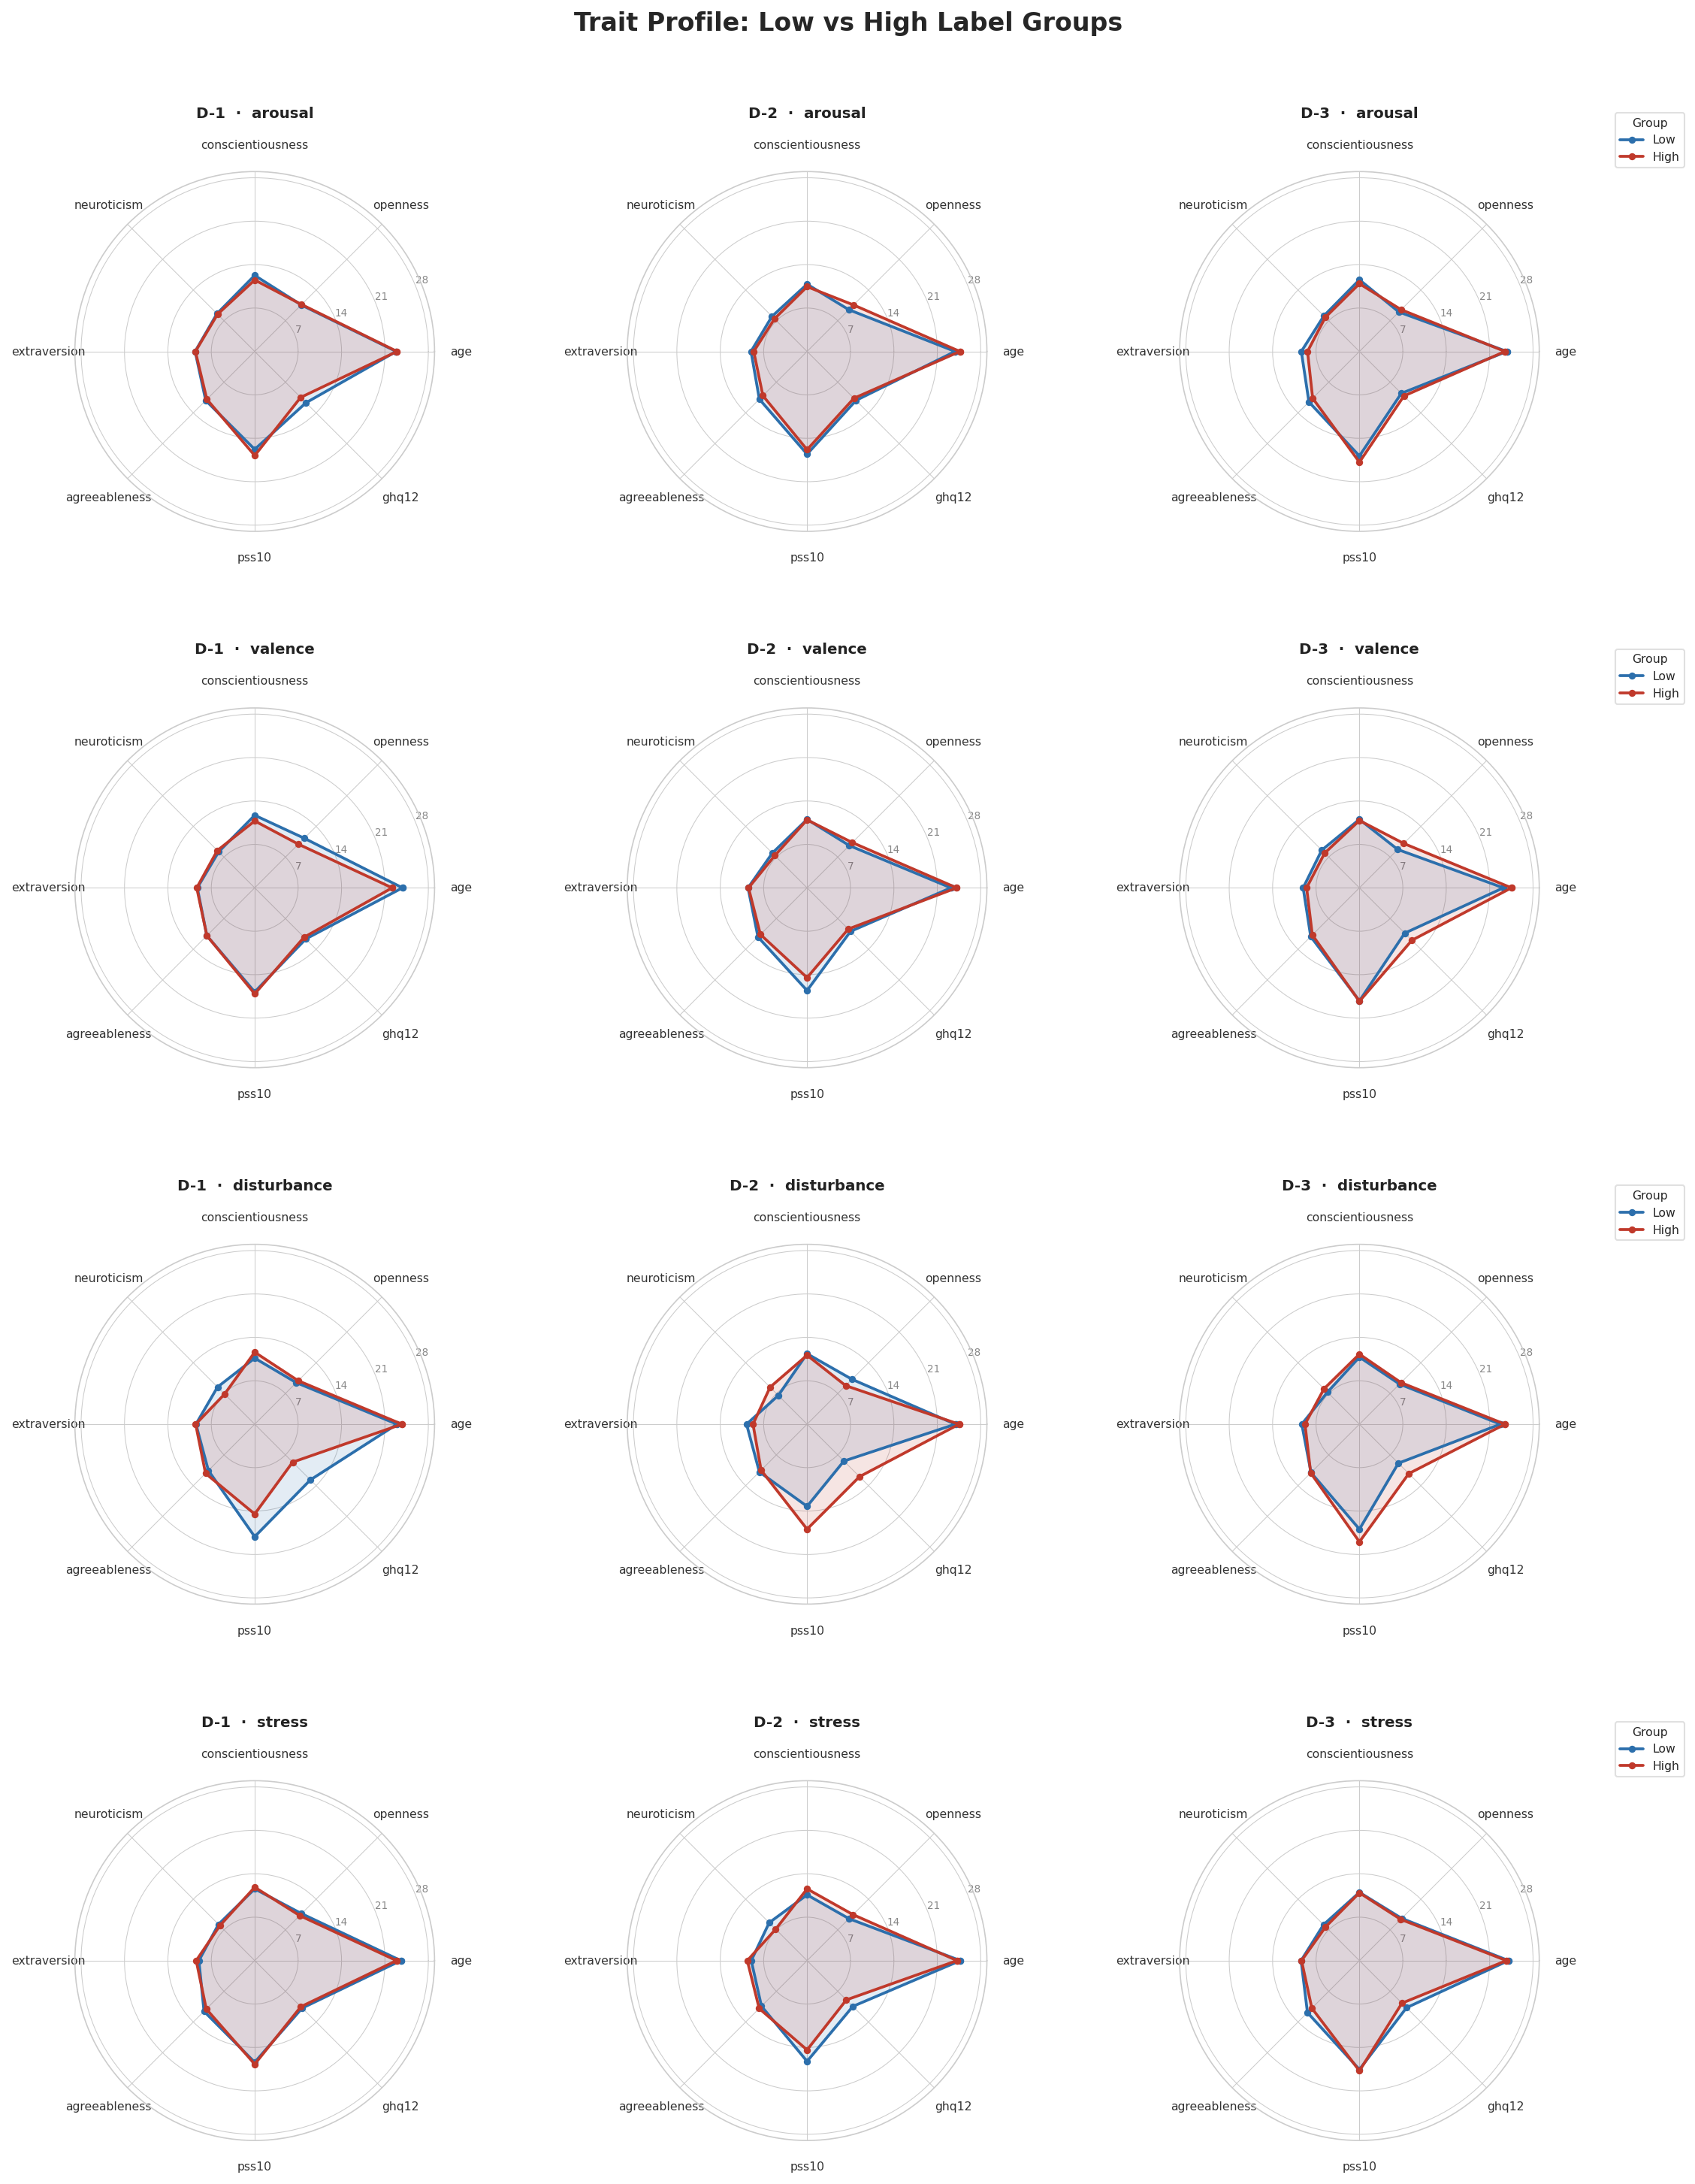

In [11]:
try:
    merged_data = build_merged_data()
except NameError:
    raise RuntimeError('build_merged_data() not defined — check Cell 4 helpers')
if merged_data.empty:
    print('merged_data is empty — skipping Trait Profile')

else: 
    LABEL_COLS  = ["arousal", "valence", "disturbance", "stress"]

    available_labels = [c for c in LABEL_COLS if c in merged_data.columns]
    available_traits = [c for c in TRAIT_COLS  if c in merged_data.columns]
    n_traits = len(available_traits)

    # ── Angles (closed loop) ─────────────────────────────────────────────────
    angles        = np.linspace(0, 2 * np.pi, n_traits, endpoint=False)
    angles_closed = np.concatenate([angles, [angles[0]]])

    # ── Pre-compute per-label y-limits so all three waves share the same scale
    label_ylims = {}
    for label in available_labels:
        all_vals = []
        for wave in WAVE_KEYS:
            ds = merged_data[merged_data["dataset"] == wave]
            if ds.empty or label not in ds.columns:
                continue
            q1, q3 = ds[label].quantile(0.25), ds[label].quantile(0.75)
            all_vals.extend(ds[ds[label] <= q1][available_traits].mean().tolist())
            all_vals.extend(ds[ds[label] >= q3][available_traits].mean().tolist())
        if all_vals:
            r_max = np.ceil(max(all_vals) * 1.15)   # 15 % headroom
            label_ylims[label] = r_max
        else:
            label_ylims[label] = 20

    # ── Colors & style constants ─────────────────────────────────────────────
    COLOR_LOW  = "#2C6FAC"
    COLOR_HIGH = "#C0392B"
    FILL_ALPHA = 0.13

    n_rows = len(available_labels)
    n_cols = len(WAVE_KEYS)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5.2 * n_cols, 4.8 * n_rows),
        subplot_kw={"polar": True},
    )

    # Ensure axes is always 2-D
    if n_rows == 1: axes = axes[np.newaxis, :]
    if n_cols == 1: axes = axes[:, np.newaxis]

    fig.suptitle("Trait Profile: Low vs High Label Groups",
                    fontweight="bold", fontsize=16, y=1.01)

    for row_idx, label in enumerate(available_labels):
        r_max = label_ylims[label]
        # Tidy tick values: 3–4 evenly spaced, whole numbers
        tick_step = max(1, round(r_max / 4))
        r_ticks   = np.arange(tick_step, r_max + 1, tick_step)

        for col_idx, wave in enumerate(WAVE_KEYS):
            ax = axes[row_idx, col_idx]
            ax.set_title(f"{wave}  ·  {label}",
                            fontsize=9.5, fontweight="bold", pad=14, color="#222222")

            # ── Axis cosmetics ────────────────────────────────────────────────
            ax.set_ylim(0, r_max)
            ax.set_yticks(r_ticks)
            ax.set_yticklabels([str(int(v)) for v in r_ticks],
                                fontsize=6.5, color="#888888")
            ax.set_xticks(angles)
            ax.set_xticklabels(available_traits, fontsize=7.5, color="#333333")
            ax.tick_params(axis="both", pad=4)

            # Subtle grid
            ax.grid(color="#cccccc", linewidth=0.5, linestyle="-")
            ax.spines["polar"].set_color("#cccccc")
            ax.spines["polar"].set_linewidth(0.8)
            ax.set_facecolor("white")

            # ── Data ─────────────────────────────────────────────────────────
            ds = merged_data[merged_data["dataset"] == wave].copy()
            if ds.empty or label not in ds.columns:
                ax.text(0, 0, "no data", ha="center", va="center",
                        transform=ax.transData, fontsize=8, color="#aaaaaa")
                continue

            q1 = ds[label].quantile(0.25)
            q3 = ds[label].quantile(0.75)
            low_means  = ds[ds[label] <= q1][available_traits].mean()
            high_means = ds[ds[label] >= q3][available_traits].mean()
            n_low  = int((ds[label] <= q1).sum())
            n_high = int((ds[label] >= q3).sum())

            vals_low  = np.concatenate([low_means.fillna(0).values,  [low_means.fillna(0).values[0]]])
            vals_high = np.concatenate([high_means.fillna(0).values, [high_means.fillna(0).values[0]]])

            # ── Plot ─────────────────────────────────────────────────────────
            ax.plot(angles_closed, vals_low,
                    color=COLOR_LOW,  linewidth=1.8, marker="o",
                    markersize=3.5, zorder=3, label="Low")
            ax.fill(angles_closed, vals_low,
                    color=COLOR_LOW,  alpha=FILL_ALPHA, zorder=2)

            ax.plot(angles_closed, vals_high,
                    color=COLOR_HIGH, linewidth=1.8, marker="o",
                    markersize=3.5, zorder=3, label="High")
            ax.fill(angles_closed, vals_high,
                    color=COLOR_HIGH, alpha=FILL_ALPHA, zorder=2)

            # Legend — only on the first column to avoid repetition
            if col_idx == n_cols - 1:
                legend = ax.legend(
                    loc="upper right",
                    bbox_to_anchor=(1.42, 1.18),
                    fontsize=7.5,
                    frameon=True,
                    framealpha=0.9,
                    edgecolor="#dddddd",
                    title="Group",
                    title_fontsize=7.5,
                )

    plt.tight_layout(h_pad=3.5, w_pad=2.5)
    plt.show()

### Trait Profile - Z-Normalized

Insight: Personality trait profiles for low vs high stress groups, normalised per wave using z-score standardization.

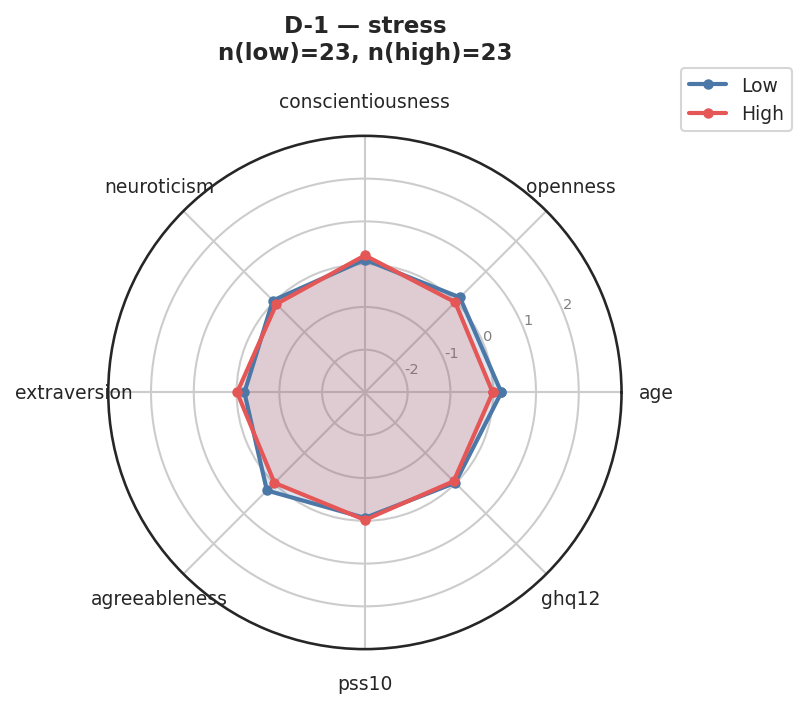

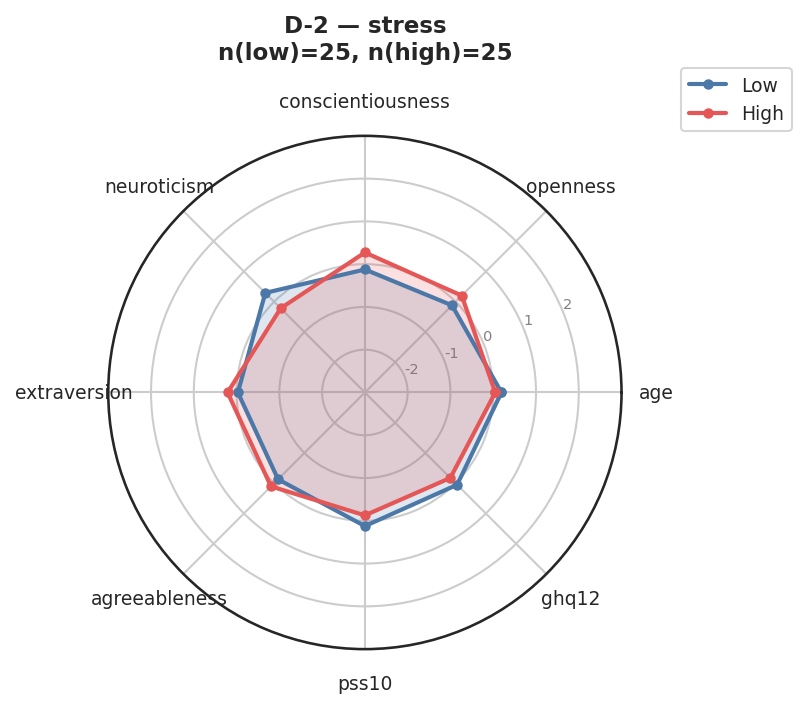

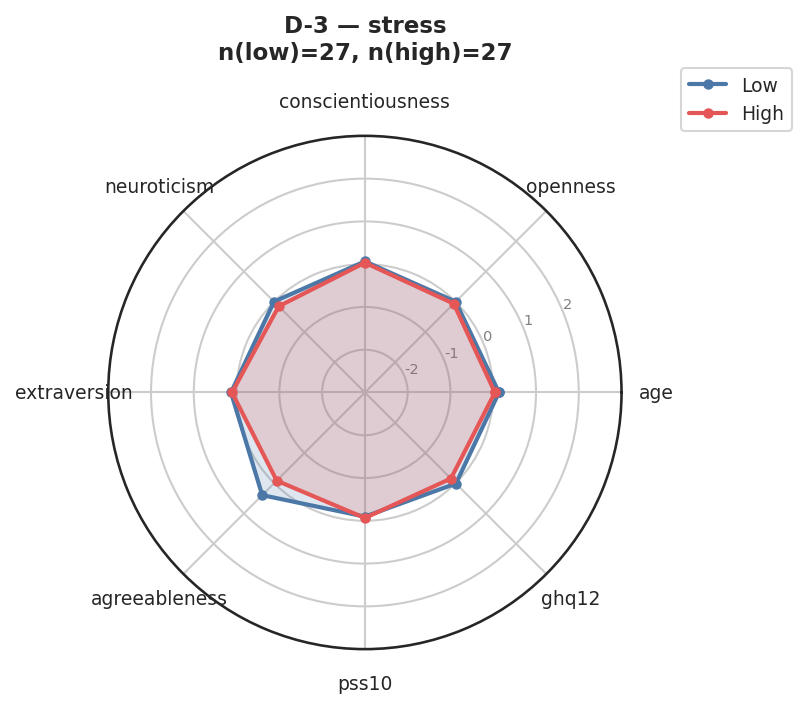

In [12]:
# ── Config ────────────────────────────────────────────────────────────────────
SELECTED_LABEL = "stress"

available_traits = [c for c in TRAIT_COLS if c in merged_data.columns]

angles        = np.linspace(0, 2 * np.pi, len(available_traits), endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])

for wave in WAVE_KEYS:
    ds_data = merged_data[merged_data["dataset"] == wave].copy()
    if ds_data.empty or SELECTED_LABEL not in ds_data.columns:
        print(f"Skipping {wave} — no data or label missing.")
        continue

    scaler = StandardScaler()
    ds_data[available_traits] = scaler.fit_transform(ds_data[available_traits])

    q1 = ds_data[SELECTED_LABEL].quantile(0.25)
    q3 = ds_data[SELECTED_LABEL].quantile(0.75)
    low_means   = ds_data[ds_data[SELECTED_LABEL] <= q1][available_traits].mean()
    high_means  = ds_data[ds_data[SELECTED_LABEL] >= q3][available_traits].mean()
    n_low  = (ds_data[SELECTED_LABEL] <= q1).sum()
    n_high = (ds_data[SELECTED_LABEL] >= q3).sum()

    vals_low  = np.concatenate([low_means.values,  [low_means.values[0]]])
    vals_high = np.concatenate([high_means.values, [high_means.values[0]]])

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})

    ax.plot(angles_closed, vals_low,  color="#4C78A8", linewidth=2, marker="o", markersize=4, label="Low")
    ax.fill(angles_closed, vals_low,  color="#4C78A8", alpha=0.18)
    ax.plot(angles_closed, vals_high, color="#E45756", linewidth=2, marker="o", markersize=4, label="High")
    ax.fill(angles_closed, vals_high, color="#E45756", alpha=0.18)

    ax.set_xticks(angles)
    ax.set_xticklabels(available_traits, fontsize=9)
    ax.set_ylim(-3, 3)
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_yticklabels(["-2", "-1", "0", "1", "2"], fontsize=7, color="gray")
    ax.tick_params(axis="y", labelsize=7)

    ax.set_title(
        f"{wave} — {SELECTED_LABEL}\n"
        f"n(low)={n_low}, n(high)={n_high}",
        fontsize=11, fontweight="bold", pad=16
    )
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9, frameon=True)

    plt.tight_layout()
    plt.show()